In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor, v2
import matplotlib.pyplot as plt

In [45]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5, 0.5), (0.5,0.5,0.5))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5, 0.5), (0.5,0.5,0.5)),
])

train_data = datasets.STL10(root='data', split='train', download=True, transform=train_transform)
test_data  = datasets.STL10(root='data', split='test',  download=True, transform=test_transform)
unlabeled_data = datasets.STL10(root='data', split='unlabeled', download=True, transform=test_transform)

In [47]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [48]:
len(train_data), len(test_data), len(unlabeled_subset)

(5000, 8000, 35000)

In [5]:
image, label = train_data[0]
image, label

(tensor([[[-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          ...,
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059]],
 
         [[-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          ...,
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059]],
 
         [[-0.9059, -0.9059, -0.9059,  ..., -0.9059, -0.9059, -0.9059],
          [-0.9059, -0.9059,

In [6]:
classes_names = train_data.classes
classes_names

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

In [7]:
image.shape

torch.Size([3, 96, 96])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90588236..1.0].


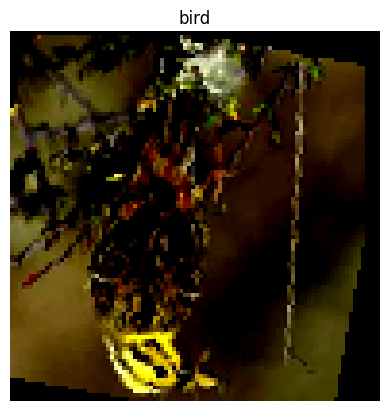

In [8]:
plt.imshow(image.permute(1,2,0))
plt.title(classes_names[label]);
plt.axis(False);

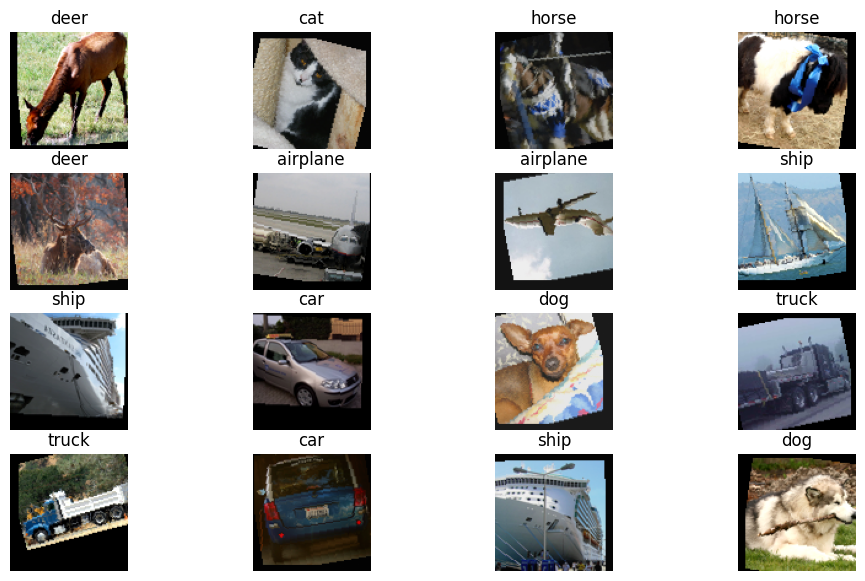

In [9]:
fig = plt.figure(figsize=(12,7))
rows, cols = 4, 4

for i in range(1, rows*cols+1):
    random_idx = torch.randint(1, len(train_data), size=[1]).item()
    img,label = train_data[random_idx]
    img = img*0.5+0.5
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.permute(1,2,0))
    plt.title(classes_names[label]);
    plt.axis(False)

In [49]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
unlabeled_dataloader = DataLoader(unlabeled_subset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

len(train_dataloader), len(test_dataloader), len(unlabeled_dataloader)

(156, 250, 1094)

In [50]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)

In [51]:
class STL10Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            ResidualBlock(32),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            ResidualBlock(64),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            ResidualBlock(128),
        )

        self.linear_block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128,10),
        )

    def forward(self, x):
        return self.linear_block(self.conv_block(x))

model = STL10Model().to(device)

In [52]:
dummy = torch.rand([1,3,96,96]).to(device)
print(model.conv_block(dummy).shape)

torch.Size([1, 128, 24, 24])


In [53]:
from torchmetrics import Accuracy

acc = Accuracy(task='multiclass', num_classes=len(classes_names))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

In [54]:
acc.to(device)

MulticlassAccuracy()

In [55]:
from tqdm.std import tqdm

best_loss = float('inf')
patience = 8
counter = 0

epochs = 0

while True:
    epochs += 1
    print(f'\nEpoch {epochs}\n-----------')
    train_loss = 0
    model.train()

    for batch, (X, y) in tqdm(enumerate(train_dataloader)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)

            test_pred = model(X_test)

            test_loss += loss_fn(test_pred, y_test)
            acc.update(test_pred.argmax(dim=1), y_test)

        test_loss /= len(test_dataloader)
        test_acc = acc.compute()
        acc.reset()

    print(f'\nTrain loss {train_loss:.4f} | Test loss {test_loss:.4f} | Test acc {test_acc * 100:.2f}%')  

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epochs,
            'loss': best_loss,
        }, 'model_params/best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print('Early stopping')
            break


Epoch 1
-----------


156it [00:15, 10.30it/s]



Train loss 1.8872 | Test loss 1.7895 | Test acc 29.36%

Epoch 2
-----------


156it [00:13, 11.93it/s]



Train loss 1.7028 | Test loss 1.6419 | Test acc 35.06%

Epoch 3
-----------


...


Train loss 0.8951 | Test loss 1.2206 | Test acc 60.06%

Epoch 31
-----------


156it [00:14, 10.54it/s]



Train loss 0.8996 | Test loss 1.0942 | Test acc 62.40%

Epoch 32
-----------


156it [00:14, 10.68it/s]



Train loss 0.8686 | Test loss 0.9536 | Test acc 67.11%
Early stopping


In [56]:
checkpoint = torch.load('model_params/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

STL10Model(
  (conv_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): ResidualBlock(
      (block): Sequential(
        (0): Con

In [57]:
CONFIDENCE_THRESHOLD = 0.90

pseudo_images = []
pseudo_labels = []

model.eval()
with torch.inference_mode():
    for X, _ in tqdm(unlabeled_dataloader):
        X = X.to(device)
        probs = torch.softmax(model(X), dim=1)
        confidence, predicted = probs.max(dim=1)

        mask = confidence >= CONFIDENCE_THRESHOLD
        pseudo_images.append(X[mask].cpu())
        pseudo_labels.append(predicted[mask].cpu())

pseudo_images = torch.cat(pseudo_images)
pseudo_labels = torch.cat(pseudo_labels)

print(f'Pseudo-labeled images: {len(pseudo_images)} / {len(unlabeled_data)}')

100%|██████████████████████████████████████████████████████████████████████████████| 1094/1094 [00:37<00:00, 29.51it/s]


Pseudo-labeled images: 4092 / 100000


In [60]:
from torch.utils.data import TensorDataset, ConcatDataset

pseudo_dataset = TensorDataset(pseudo_images, pseudo_labels.long())

class LabelToTensor(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, torch.tensor(label)

combined_dataset = ConcatDataset([LabelToTensor(train_data), pseudo_dataset])
combined_dataloader = DataLoader(combined_dataset, batch_size=32, shuffle=True, drop_last=True)

In [61]:
best_loss = float('inf')
patience = 8
counter = 0

epochs = 0

while True:
    epochs += 1
    print(f'\nEpoch {epochs}\n-----------')
    train_loss = 0
    model.train()

    for batch, (X, y) in tqdm(enumerate(combined_dataloader)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
            train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)

            test_pred = model(X_test)

            test_loss += loss_fn(test_pred, y_test)
            acc.update(test_pred.argmax(dim=1), y_test)

        test_loss /= len(test_dataloader)
        test_acc = acc.compute()
        acc.reset()

    print(f'\nTrain loss {train_loss:.4f} | Test loss {test_loss:.4f} | Test acc {test_acc * 100:.2f}%')  

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epochs,
            'loss': best_loss,
        }, 'model_params/best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print('Early stopping')
            break


Epoch 1
-----------


284it [00:13, 21.12it/s]



Train loss 1.0945 | Test loss 1.0464 | Test acc 63.89%

Epoch 2
-----------


284it [00:14, 19.07it/s]



Train loss 1.0795 | Test loss 1.1285 | Test acc 61.77%

Epoch 3
-----------


...


Train loss 0.8287 | Test loss 0.9222 | Test acc 68.97%

Epoch 27
-----------


284it [00:13, 21.00it/s]



Train loss 0.8064 | Test loss 1.0007 | Test acc 67.81%

Epoch 28
-----------


284it [00:15, 17.96it/s]



Train loss 0.8170 | Test loss 0.9423 | Test acc 69.95%
Early stopping


In [63]:
img, label = test_data[250]
img = img.unsqueeze(0).to(device)

with torch.inference_mode():
    pred = model(img)
    pred_class = pred.argmax(dim=1).item()

print(f'Predicted: {classes_names[pred_class]} | Actual: {classes_names[label]}')

Predicted: airplane | Actual: airplane


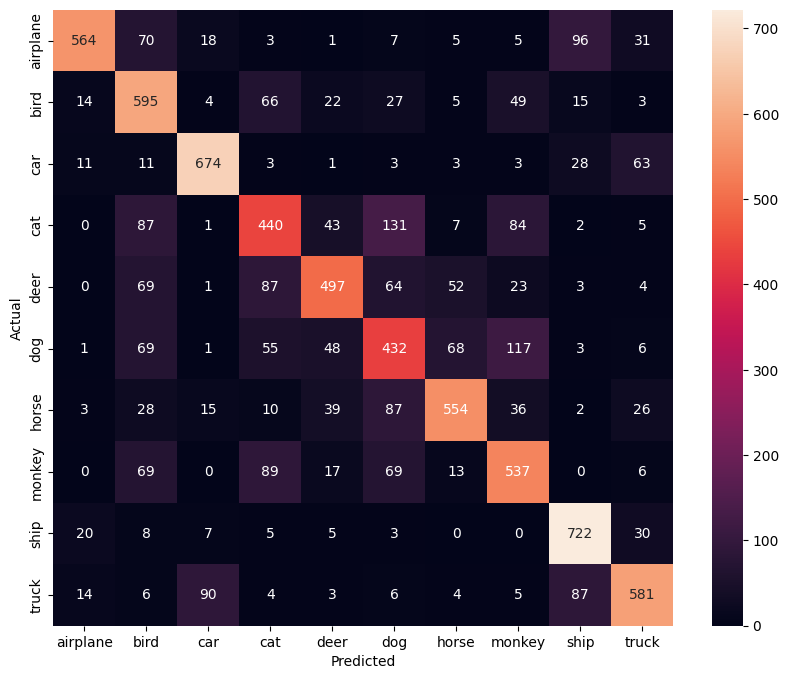

In [64]:
from torchmetrics import ConfusionMatrix
import seaborn as sns

confmat = ConfusionMatrix(task='multiclass', num_classes=10).to(device)

model.eval()
with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        confmat.update(model(X_test).argmax(dim=1), y_test)

matrix = confmat.compute().cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='g',
            xticklabels=classes_names,
            yticklabels=classes_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# The model does a good job of distinguishing between vehicles and animals, but it struggles to distinguish between different types of animals within the same category. This is an issue for CNNs without transfer learning — there isn’t enough data to learn the subtle differences between similar classes.

# Adding a learning rate scheduler resulted in only a negligible improvement in test accuracy (69.71% → 69.82%), indicating that further gains are unlikely to come from scheduler tuning and that the current architecture may have reached its performance limit.

# Tried adding pseudo-labeling pipeline using unlabeled STL10 split, but acc did not improved
